# Pipeline Completo de PLN sobre o Corpus BBC News

**Aluno:** Anderson Correa

**Disciplina:** Processamento de Linguagem Natural (Sistemas Cognitivos e Linguagem Natural)

---

## Problema

> **Como construir um pipeline completo de PLN que transforme um corpus textual
> bruto em informação útil — combinando pré-processamento, representação
> vetorial, busca, classificação, modelagem de tópicos, extração de entidades,
> grafo de conhecimento e visualização?**

O corpus escolhido foi o **BBC News** (2.225 notícias em 5 editorias). A partir
dele, o notebook percorre todas as etapas exigidas: caracterização e limpeza do texto, transformação em vetores,
aplicação de modelos supervisionados e não supervisionados, extração de entidades e
relações, e comunicação de resultados.

## 1. Configuração e reprodutibilidade

Esta seção fixa o ambiente do pipeline. O projeto é gerenciado com **uv**
(Python 3.12) e todas as dependências estão travadas em `uv.lock`. Os dados do
NLTK ficam em um diretório local ao projeto (`nltk_data/`) e o modelo do spaCy
(`en_core_web_sm`) é declarado como dependência, eliminando passos manuais de
download. Fixamos `random_state = 42` em todas as etapas estocásticas
(divisão treino/teste, t-SNE, Word2Vec, modelagem de tópicos) para garantir
resultados determinísticos.

A célula a seguir carrega o corpus já caracterizado (`data/processed.parquet`),
define os diretórios de saída e imprime as versões das principais bibliotecas.


In [1]:
# --- Master setup: imports, paths, reproducibility ---
from pathlib import Path

import matplotlib
matplotlib.use("Agg")

import nltk
import numpy as np
import pandas as pd
from IPython.display import Image, display

# Resolve the project root whether the kernel starts in the repo root or notebooks/.
NB_ROOT = Path.cwd()
if not (NB_ROOT / "data" / "processed.parquet").exists():
    NB_ROOT = NB_ROOT.parent
assert (NB_ROOT / "data" / "processed.parquet").exists(), (
    "processed.parquet not found - run scripts/build_processed.py first"
)

nltk.data.path.insert(0, str(NB_ROOT / "nltk_data"))

PROJECT_ROOT = NB_ROOT
DATA_DIR = NB_ROOT / "data"
FIG_DIR = NB_ROOT / "outputs" / "figures"
MODEL_DIR = NB_ROOT / "outputs" / "models"
GRAPH_DIR = NB_ROOT / "outputs" / "graph"
for _d in (FIG_DIR, MODEL_DIR, GRAPH_DIR):
    _d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DF = pd.read_parquet(DATA_DIR / "processed.parquet")
print(f"Corpus loaded: {DF.shape[0]} documents, {DF['category'].nunique()} categories")

import sklearn
import spacy
import gensim
import networkx
print(f"pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__}")
print(f"spaCy {spacy.__version__} | gensim {gensim.__version__} | networkx {networkx.__version__}")


Corpus loaded: 2225 documents, 5 categories


pandas 3.0.3 | numpy 1.26.4 | scikit-learn 1.4.2
spaCy 3.7.5 | gensim 4.4.0 | networkx 3.6.1


## 2. Carga e inspeção do corpus

O corpus **BBC News** (D. Greene e P. Cunningham, ICML 2006 — fonte:
http://mlg.ucd.ie/datasets/bbc.html) reúne **2.225 notícias** publicadas pela
BBC em 2004-2005, distribuídas em **5 editorias**: *business*, *entertainment*,
*politics*, *sport* e *tech*. As classes são razoavelmente equilibradas (de 386
a 511 documentos por categoria), o que dispensa reamostragem e simplifica a
avaliação dos classificadores.

**Por que este corpus?** Ele satisfaz simultaneamente todos os critérios
exigidos: tem volume suficiente (> 1.000 documentos), textos longos (média de
~384 palavras por documento, bem acima do mínimo recomendado de 200), rótulos
claros para classificação, e é densamente povoado por **entidades nomeadas**
(pessoas, organizações, lugares) — matéria-prima ideal para NER e para o grafo
de conhecimento. Além disso, é público, citável e roda em CPU, sem GPU.

A inspeção inicial confirma a distribuição de classes e o comprimento dos
documentos por categoria.


In [2]:
# --- Setup and imports ---
import matplotlib

matplotlib.use("Agg")

import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import spacy
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import sent_tokenize, word_tokenize
from wordcloud import WordCloud

PROJECT_ROOT = NB_ROOT
nltk.data.path.insert(0, str(PROJECT_ROOT / "nltk_data"))

DF = pd.read_parquet(PROJECT_ROOT / "data" / "processed.parquet")
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

# Domain stopwords: high-frequency reporting verbs and filler that carry no
# topical signal in news prose (mirrors scripts/build_processed.py).
CUSTOM_STOPWORDS = {
    "said", "say", "says", "mr", "mrs", "ms", "would", "could", "also",
    "one", "two", "year", "years", "told", "added", "new", "make", "made",
    "get", "go", "going", "us", "uk",
}

In [3]:
# --- Corpus inspection ---
def class_distribution(frame):
    """Return the document count per category, descending."""
    return frame["category"].value_counts()


def plot_class_distribution(frame, path):
    """Save a bar chart of document counts per category."""
    counts = class_distribution(frame)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(counts.index, counts.values, color="#4C72B0")
    ax.set_title("Document count per category (BBC News)")
    ax.set_xlabel("Category")
    ax.set_ylabel("Documents")
    for i, c in enumerate(counts.values):
        ax.text(i, c, str(c), ha="center", va="bottom")
    fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.close(fig)


def plot_length_histogram(frame, path):
    """Save a histogram of raw document length (words) by category."""
    fig, ax = plt.subplots(figsize=(9, 5))
    for category in sorted(frame["category"].unique()):
        subset = frame.loc[frame["category"] == category, "n_words_raw"]
        ax.hist(subset, bins=40, alpha=0.5, label=category)
    ax.set_title("Raw document length distribution by category")
    ax.set_xlabel("Words per document")
    ax.set_ylabel("Documents")
    ax.set_xlim(0, 1200)
    ax.legend()
    fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.close(fig)

In [4]:
# --- Tokenization and normalization demo ---
def normalize(text):
    """Lowercase and strip everything except ASCII letters and spaces."""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def demo_tokenization(sample_text):
    """Print sentence and word tokenization of a sample document."""
    sentences = sent_tokenize(sample_text)
    words = word_tokenize(sample_text)
    print(f"Sentences found: {len(sentences)}")
    print(f"First sentence: {sentences[0]}")
    print(f"Word tokens (first 25): {words[:25]}")
    return sentences, words

In [5]:
# --- Stopword removal ---
def build_stopwords():
    """Return the union of NLTK English stopwords and custom domain stopwords."""
    return set(stopwords.words("english")) | CUSTOM_STOPWORDS


def base_tokens(text, stop):
    """Normalize, tokenize, and drop stopwords/short tokens for one document.

    Produces the shared base used for the fair stemming-vs-lemmatization
    comparison.
    """
    tokens = word_tokenize(normalize(text))
    return [t for t in tokens if t.isalpha() and len(t) > 2 and t not in stop]

In [6]:
# --- Stemming vs lemmatization comparison ---
def compare_stemming_lemmatization(frame, stop):
    """Compare vocabulary collapse of stemming vs lemmatization on one base.

    Both Porter stemming and WordNet lemmatization are applied to an identical
    base-token corpus so the comparison isolates the morphological operation.

    Returns a tuple of (summary DataFrame, example DataFrame).
    """
    stemmer = PorterStemmer()
    lemmatizer = WordNetLemmatizer()

    base_vocab = set()
    stem_vocab = set()
    lemma_vocab = set()
    for text in frame["text"]:
        for token in base_tokens(text, stop):
            base_vocab.add(token)
            stem_vocab.add(stemmer.stem(token))
            lemma_vocab.add(lemmatizer.lemmatize(token))

    base_n = len(base_vocab)
    summary = pd.DataFrame(
        {
            "technique": ["Base (no stopwords)", "Porter stemming", "WordNet lemmatization"],
            "vocab_size": [base_n, len(stem_vocab), len(lemma_vocab)],
        }
    )
    summary["reduction_vs_base_%"] = (
        (base_n - summary["vocab_size"]) / base_n * 100
    ).round(1)

    sample_words = [
        "studies", "studying", "studied", "national", "nationalisation",
        "running", "better", "organisation", "policies", "winning",
        "companies", "argued",
    ]
    examples = pd.DataFrame(
        {
            "word": sample_words,
            "porter_stem": [stemmer.stem(w) for w in sample_words],
            "wordnet_lemma": [lemmatizer.lemmatize(w) for w in sample_words],
        }
    )
    return summary, examples

In [7]:
# --- POS tagging with spaCy ---
def pos_distribution(frame, sample_size=500, random_state=42):
    """Compute the coarse POS-tag distribution over a sample using spaCy.

    A sample keeps the demonstration fast; the distribution is stable across
    samples for a corpus this homogeneous.
    """
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "lemmatizer"])
    sample = frame.sample(min(sample_size, len(frame)), random_state=random_state)
    counter = Counter()
    for doc in nlp.pipe(sample["text"].tolist(), batch_size=64):
        for token in doc:
            if not token.is_space and not token.is_punct:
                counter[token.pos_] += 1
    return counter


def demo_pos_tagging(sample_sentence):
    """Print the POS tags of a sample sentence with spaCy."""
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "lemmatizer"])
    doc = nlp(sample_sentence)
    pairs = [(token.text, token.pos_, token.tag_) for token in doc][:15]
    for text, pos, tag in pairs:
        print(f"  {text:<15} {pos:<8} {tag}")
    return pairs


def plot_pos_distribution(counter, path):
    """Save a bar chart of the POS-tag distribution."""
    items = counter.most_common()
    tags = [t for t, _ in items]
    counts = [c for _, c in items]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(tags, counts, color="#55A868")
    ax.set_title("POS-tag distribution (spaCy, sampled documents)")
    ax.set_xlabel("Universal POS tag")
    ax.set_ylabel("Token count")
    plt.xticks(rotation=45, ha="right")
    fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.close(fig)

In [8]:
# --- Word cloud and top terms ---
def plot_wordcloud(frame, path):
    """Save a word cloud of the cleaned corpus text."""
    text = " ".join(frame["clean_text"].fillna(""))
    cloud = WordCloud(width=1200, height=600, background_color="white",
                      colormap="viridis", max_words=150).generate(text)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(cloud, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Word cloud of cleaned BBC corpus")
    fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.close(fig)


def top_terms(frame, top_n=25):
    """Return the most frequent cleaned tokens across the corpus."""
    counter = Counter()
    for tokens in frame["tokens"]:
        counter.update(tokens)
    return counter.most_common(top_n)


def plot_top_terms(frame, path, top_n=25):
    """Save a horizontal bar chart of the most frequent cleaned tokens."""
    items = top_terms(frame, top_n)
    terms = [t for t, _ in items][::-1]
    counts = [c for _, c in items][::-1]
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.barh(terms, counts, color="#C44E52")
    ax.set_title(f"Top {top_n} terms in cleaned corpus")
    ax.set_xlabel("Frequency")
    fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.close(fig)

## 3. Pré-processamento textual (NLTK + spaCy)

O pré-processamento converte texto bruto em tokens limpos e comparáveis. O
pipeline aplica, em ordem: **normalização** (minúsculas, remoção de pontuação,
dígitos e símbolos), **tokenização** de palavras e de sentenças (NLTK),
**remoção de stopwords** (as 198 stopwords do inglês do NLTK acrescidas de 23
stopwords customizadas de domínio jornalístico, como *said*, *mr*, *would*,
*also*, que sobrevivem à lista genérica mas não carregam sinal temático) e,
por fim, **lematização**.

### Stemming vs. lematização

Comparamos as duas estratégias de redução morfológica sobre uma **base de tokens
idêntica**, para isolar o efeito da operação. O **stemming de Porter** é
agressivo: corta sufixos sem consultar um dicionário, colapsando o vocabulário
em ~32%, mas gerando radicais que não são palavras reais (*studies* → *studi*,
*policies* → *polici*, *companies* → *compani*). A **lematização** (WordNet) é
conservadora (~11% de redução) e preserva palavras válidas (*policies* →
*policy*).

**Decisão de projeto:** a coluna canônica `clean_text`, usada em toda a etapa
seguinte (busca, tópicos, rótulos do grafo), foi gerada com **lematização do
spaCy**, não com stemming. O motivo é direto: radicais mutilados prejudicariam a
legibilidade dos termos de busca, das palavras-chave dos tópicos e dos rótulos
do grafo de conhecimento. O stemming permanece como demonstração comparativa,
não como caminho de produção. (Demonstramos dois lematizadores — WordNet na
comparação e spaCy na produção — evidenciando o domínio das ferramentas.)

A análise de **POS tagging** com spaCy e o impacto do pré-processamento no
vocabulário são apresentados a seguir, junto da nuvem de palavras, do histograma
de comprimento e da distribuição de classes gramaticais.


In [9]:
# --- Main ---
def main():
    """Run inspection and preprocessing evidence end to end."""
    print(f"Corpus shape: {DF.shape}")
    print("\nClass distribution:\n", class_distribution(DF).to_string())
    print(f"\nMean raw words/doc:   {DF['n_words_raw'].mean():.1f}")
    print(f"Mean clean words/doc: {DF['n_words_clean'].mean():.1f}")
    print("\nLength by category (raw words):")
    print(DF.groupby("category")["n_words_raw"].describe()[["mean", "50%", "std"]].round(1).to_string())

    plot_class_distribution(DF, FIG_DIR / "02_class_distribution.png")
    plot_length_histogram(DF, FIG_DIR / "03_doc_length_hist.png")

    print("\n=== Tokenization demo ===")
    demo_tokenization(DF.iloc[0]["text"])

    stop = build_stopwords()
    print(f"\nStopwords: {len(stopwords.words('english'))} NLTK + "
          f"{len(CUSTOM_STOPWORDS)} custom = {len(stop)} total")

    print("\n=== Stemming vs lemmatization ===")
    summary, examples = compare_stemming_lemmatization(DF, stop)
    print(summary.to_string(index=False))
    print("\nExamples:")
    print(examples.to_string(index=False))

    print("\n=== POS tagging demo ===")
    demo_pos_tagging(sent_tokenize(DF.iloc[0]["text"])[0])
    pos_counter = pos_distribution(DF)
    print("\nPOS distribution (sample):")
    for tag, count in pos_counter.most_common():
        print(f"  {tag:<8} {count}")
    plot_pos_distribution(pos_counter, FIG_DIR / "03_pos_distribution.png")

    plot_wordcloud(DF, FIG_DIR / "03_wordcloud.png")
    plot_top_terms(DF, FIG_DIR / "03_top_terms.png")
    print("\nSection 2-3 figures written.")


main()

Corpus shape: (2225, 8)

Class distribution:
 category
sport            511
business         510
politics         417
tech             401
entertainment    386

Mean raw words/doc:   384.0
Mean clean words/doc: 199.3

Length by category (raw words):
                mean    50%    std
category                          
business       328.9  297.0  135.9
entertainment  330.6  262.5  261.8
politics       454.0  439.0  300.1
sport          329.3  288.0  188.0
tech           502.7  447.0  239.8



=== Tokenization demo ===
Sentences found: 21
First sentence: Ad sales boost Time Warner profit.
Word tokens (first 25): ['Ad', 'sales', 'boost', 'Time', 'Warner', 'profit', '.', 'Quarterly', 'profits', 'at', 'US', 'media', 'giant', 'TimeWarner', 'jumped', '76', '%', 'to', '$', '1.13bn', '(', '£600m', ')', 'for', 'the']

Stopwords: 198 NLTK + 23 custom = 221 total

=== Stemming vs lemmatization ===


            technique  vocab_size  reduction_vs_base_%
  Base (no stopwords)       27518                  0.0
      Porter stemming       18806                 31.7
WordNet lemmatization       24549                 10.8

Examples:
           word porter_stem   wordnet_lemma
        studies       studi           study
       studying       studi        studying
        studied       studi         studied
       national      nation        national
nationalisation  nationalis nationalisation
        running         run         running
         better      better          better
   organisation     organis    organisation
       policies      polici          policy
        winning         win         winning
      companies     compani         company
         argued        argu          argued

=== POS tagging demo ===


  Ad              NOUN     NN
  sales           NOUN     NNS
  boost           VERB     VBP
  Time            PROPN    NNP
  Warner          PROPN    NNP
  profit          NOUN     NN
  .               PUNCT    .



POS distribution (sample):
  NOUN     41567
  VERB     23741
  ADP      23332
  PROPN    22389
  DET      19810
  ADJ      14382
  AUX      13973
  PRON     10607
  ADV      6996
  PART     6711
  CCONJ    5561
  NUM      4815
  SCONJ    3001
  SYM      518
  INTJ     38
  X        28
  PUNCT    7



Section 2-3 figures written.


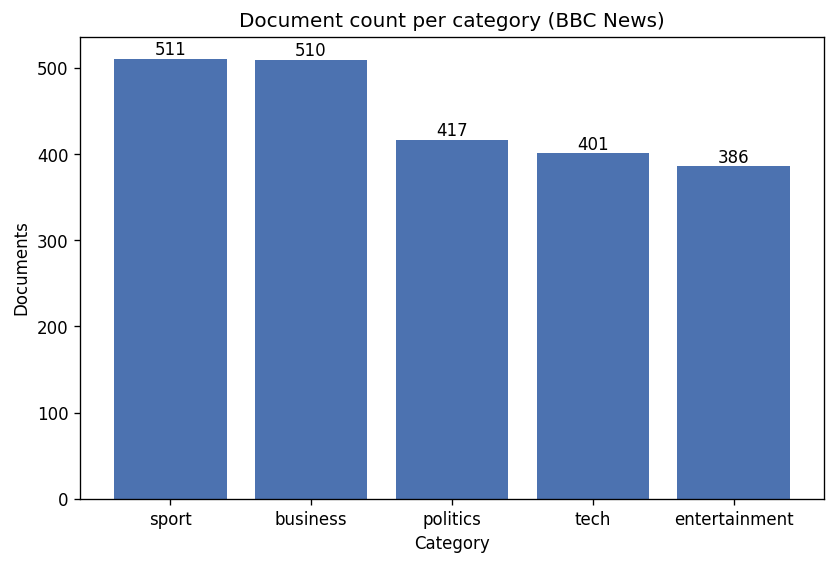

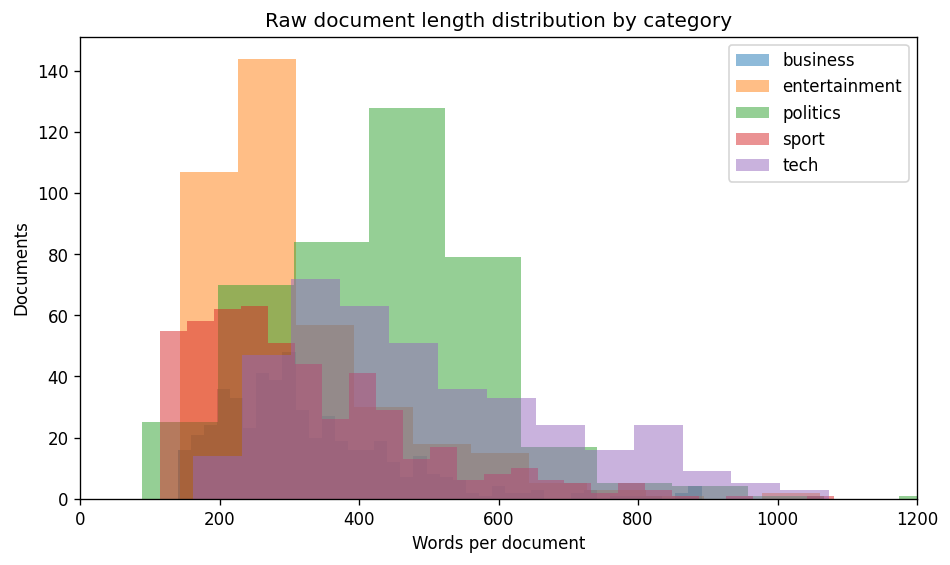

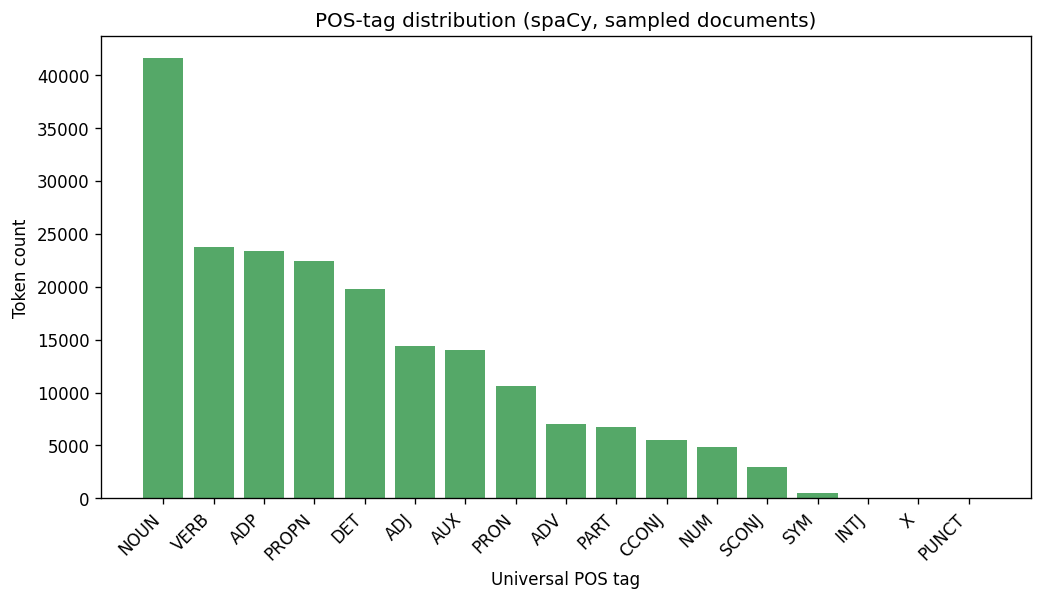

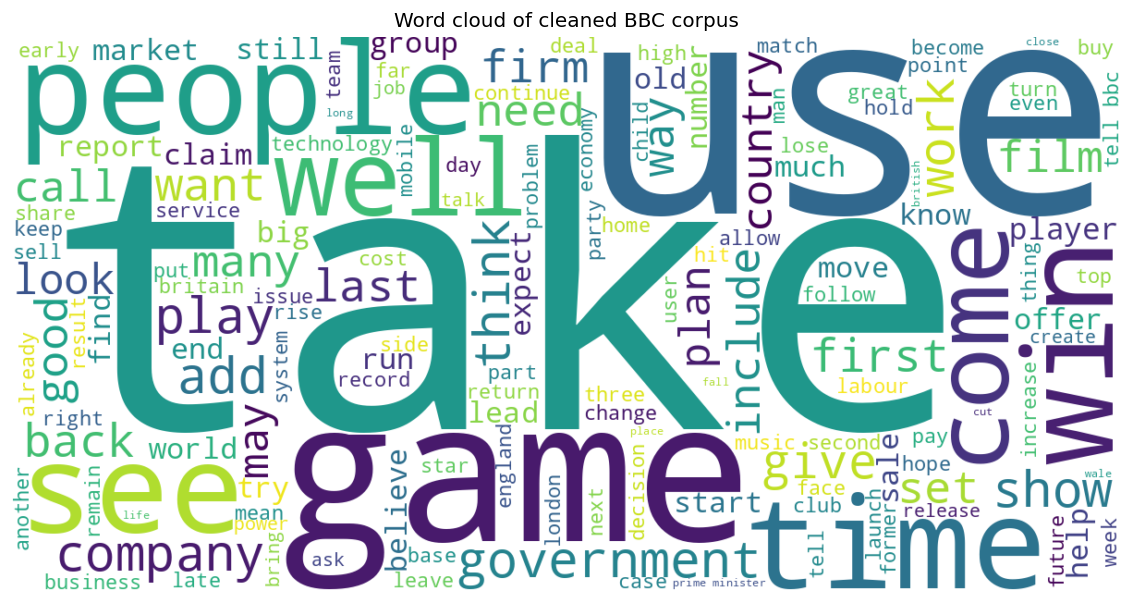

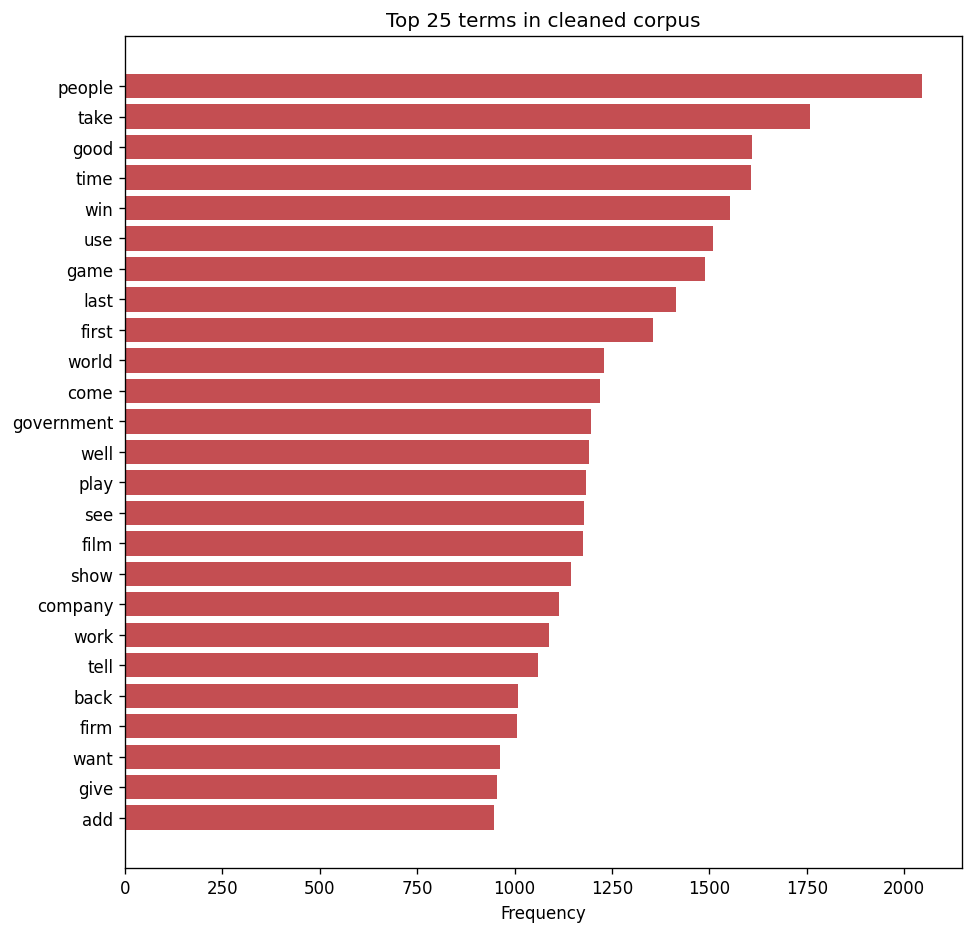

In [10]:
# Display saved figures inline
for _name in ["02_class_distribution.png", "03_doc_length_hist.png", "03_pos_distribution.png", "03_wordcloud.png", "03_top_terms.png"]:
    display(Image(filename=str(FIG_DIR / _name)))

## 4. Representação vetorial e busca textual

Para transformar os textos em vetores numéricos exploramos três abordagens
complementares. A primeira, **Bag-of-Words** (CountVectorizer sobre o
`clean_text`), gerou um vocabulário de **21.958 termos**. Ela apenas conta
ocorrências, de modo que palavras genéricas e muito frequentes dominam o ranking,
sem distinguir o que é realmente discriminativo.

A segunda, **TF-IDF com n-gramas (1,2)**, pondera cada termo pela sua raridade no
corpus e incorpora bigramas, elevando o vocabulário para **76.012 termos**. Os
termos de maior peso médio já refletem melhor os temas do corpus (*film*, *game*,
*win*, *government*, *election*, *labour*), pois o componente IDF penaliza
palavras onipresentes e valoriza vocabulário característico de cada categoria.

Escolhemos o **TF-IDF como base do motor de busca** justamente por essa
propriedade: ele realça os termos distintivos e, combinado com a **similaridade
do cosseno**, mede a proximidade temática entre a consulta e cada documento de
forma robusta ao tamanho do texto. A consulta é projetada no mesmo espaço
vetorial ajustado e ranqueada contra todos os documentos. Os resultados
confirmam a qualidade da abordagem: a busca por *"stock market interest rates and
economy"* retorna exclusivamente notícias de **business**; *"new smartphone
mobile technology"* recupera apenas matérias de **tech** sobre celulares; e
*"football championship final match"* traz majoritariamente conteúdo de
**sport**. As pontuações relativamente baixas (em torno de 0,2-0,3) são esperadas
em consultas curtas sobre documentos longos, mas a ordenação por relevância é
coerente.

A terceira abordagem, **Word2Vec** (vector_size=100, window=5, min_count=5),
aprende embeddings densos a partir do contexto, capturando relações semânticas.
Os vizinhos mais próximos são plausíveis: *film* aproxima-se de *award*, *star* e
*actor*; *government* de *security* e *plan*.

Por fim, a visualização **t-SNE** (TF-IDF reduzido via TruncatedSVD para 50
dimensões e depois projetado em 2D) mostra **cinco agrupamentos nítidos por
categoria**. *Sport* e *entertainment* ficam bem isolados, enquanto *business* e
*politics* aparecem adjacentes, com pequena sobreposição decorrente do
vocabulário econômico e de políticas públicas que ambos compartilham. Isso
evidencia que as representações vetoriais capturam bem a estrutura temática do
corpus.


In [11]:
# --- Setup and imports ---
import matplotlib

matplotlib.use("Agg")

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

PROJECT_ROOT = NB_ROOT
DF = pd.read_parquet(PROJECT_ROOT / "data" / "processed.parquet")
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
MODEL_DIR = PROJECT_ROOT / "outputs" / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
CLEAN_TEXT = DF["clean_text"].fillna("").tolist()

In [12]:
# --- Bag-of-Words (CountVectorizer) ---
def build_bag_of_words(documents):
    """Fit a CountVectorizer on the documents and return the vectorizer and matrix.

    Args:
        documents: Iterable of normalized text strings.

    Returns:
        Tuple of (fitted CountVectorizer, sparse document-term matrix).
    """
    vectorizer = CountVectorizer()
    matrix = vectorizer.fit_transform(documents)
    return vectorizer, matrix


def top_terms_by_count(vectorizer, matrix, top_n=20):
    """Return the most frequent terms across the whole corpus.

    Args:
        vectorizer: Fitted CountVectorizer.
        matrix: Document-term count matrix.
        top_n: Number of terms to return.

    Returns:
        List of (term, total_count) tuples sorted descending by count.
    """
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    order = counts.argsort()[::-1][:top_n]
    return [(terms[i], int(counts[i])) for i in order]


bow_vectorizer, bow_matrix = build_bag_of_words(CLEAN_TEXT)
bow_vocab_size = len(bow_vectorizer.vocabulary_)
bow_top_terms = top_terms_by_count(bow_vectorizer, bow_matrix, top_n=20)

print("=== Bag-of-Words ===")
print(f"BoW matrix shape: {bow_matrix.shape}")
print(f"BoW vocabulary size: {bow_vocab_size}")
print("Top 20 BoW terms (by total count):")
for term, count in bow_top_terms:
    print(f"  {term}: {count}")

=== Bag-of-Words ===
BoW matrix shape: (2225, 21958)
BoW vocabulary size: 21958
Top 20 BoW terms (by total count):
  people: 2046
  take: 1759
  good: 1609
  time: 1607
  win: 1552
  use: 1509
  game: 1488
  last: 1414
  first: 1356
  world: 1229
  come: 1219
  government: 1196
  well: 1192
  play: 1184
  see: 1178
  film: 1175
  show: 1145
  company: 1114
  work: 1088
  tell: 1059


In [13]:
# --- TF-IDF with n-grams ---
def build_tfidf(documents, ngram_range=(1, 2), min_df=2, max_df=0.9):
    """Fit a TfidfVectorizer (unigrams + bigrams) and return vectorizer and matrix.

    Args:
        documents: Iterable of normalized text strings.
        ngram_range: N-gram range passed to TfidfVectorizer.
        min_df: Minimum document frequency for a term to be kept.
        max_df: Maximum document frequency (proportion) for a term.

    Returns:
        Tuple of (fitted TfidfVectorizer, sparse TF-IDF matrix).
    """
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range, min_df=min_df, max_df=max_df
    )
    matrix = vectorizer.fit_transform(documents)
    return vectorizer, matrix


def top_terms_by_mean_tfidf(vectorizer, matrix, top_n=20):
    """Return terms ranked by their mean TF-IDF weight across the corpus.

    Args:
        vectorizer: Fitted TfidfVectorizer.
        matrix: TF-IDF document-term matrix.
        top_n: Number of terms to return.

    Returns:
        List of (term, mean_tfidf) tuples sorted descending.
    """
    mean_weights = np.asarray(matrix.mean(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    order = mean_weights.argsort()[::-1][:top_n]
    return [(terms[i], float(mean_weights[i])) for i in order]


tfidf_vectorizer, tfidf_matrix = build_tfidf(CLEAN_TEXT)
tfidf_vocab_size = len(tfidf_vectorizer.vocabulary_)
tfidf_top_terms = top_terms_by_mean_tfidf(tfidf_vectorizer, tfidf_matrix, top_n=20)

print("\n=== TF-IDF (ngram_range=(1,2)) ===")
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"TF-IDF vocabulary size: {tfidf_vocab_size}")
print("Top 20 TF-IDF terms (by mean weight):")
for term, weight in tfidf_top_terms:
    print(f"  {term}: {weight:.5f}")


=== TF-IDF (ngram_range=(1,2)) ===
TF-IDF matrix shape: (2225, 76012)
TF-IDF vocabulary size: 76012
Top 20 TF-IDF terms (by mean weight):
  film: 0.01449
  game: 0.01408
  win: 0.01371
  people: 0.01370
  good: 0.01250
  take: 0.01176
  play: 0.01136
  time: 0.01108
  use: 0.01102
  government: 0.01083
  last: 0.01062
  first: 0.01058
  world: 0.01056
  company: 0.01052
  show: 0.01029
  firm: 0.00979
  labour: 0.00947
  come: 0.00921
  election: 0.00921
  work: 0.00896


In [14]:
# --- TF-IDF top-terms bar chart ---
def plot_top_tfidf_terms(top_terms, out_path):
    """Save a horizontal bar chart of the top mean TF-IDF terms.

    Args:
        top_terms: List of (term, mean_tfidf) tuples.
        out_path: Destination path for the PNG figure.
    """
    terms = [t for t, _ in top_terms][::-1]
    weights = [w for _, w in top_terms][::-1]
    plt.figure(figsize=(9, 8))
    plt.barh(terms, weights, color="#3b7dd8")
    plt.xlabel("Mean TF-IDF weight")
    plt.title("Top terms by mean TF-IDF (unigrams + bigrams)")
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.close()


plot_top_tfidf_terms(tfidf_top_terms, FIG_DIR / "04_tfidf_top_terms.png")

In [15]:
# --- TF-IDF cosine-similarity search engine ---
def search(query, top_n=5):
    """Search the corpus for documents most similar to a free-text query.

    The query is projected into the fitted TF-IDF space and ranked by cosine
    similarity against every document in the corpus.

    Args:
        query: Free-text search string.
        top_n: Number of top results to return.

    Returns:
        List of dicts with keys id, category, title, score, ordered by score.
    """
    query_vector = tfidf_vectorizer.transform([query])
    scores = cosine_similarity(query_vector, tfidf_matrix).ravel()
    top_idx = scores.argsort()[::-1][:top_n]
    results = []
    for idx in top_idx:
        row = DF.iloc[idx]
        results.append(
            {
                "id": int(row["id"]),
                "category": str(row["category"]),
                "title": str(row["title"]),
                "score": float(scores[idx]),
            }
        )
    return results


SEARCH_QUERIES = [
    "stock market interest rates and economy",
    "football championship final match",
    "new smartphone mobile technology",
]

print("\n=== TF-IDF Search Engine ===")
for query in SEARCH_QUERIES:
    print(f'\nQuery: "{query}"')
    for rank, hit in enumerate(search(query, top_n=5), start=1):
        print(
            f"  {rank}. [{hit['category']}] {hit['title']} "
            f"(score={hit['score']:.4f})"
        )


=== TF-IDF Search Engine ===

Query: "stock market interest rates and economy"
  1. [business] Booming markets shed few tears (score=0.2929)
  2. [business] Standard Life cuts policy bonuses (score=0.2678)
  3. [business] Axa Sun Life cuts bonus payments (score=0.2002)
  4. [business] Markets signal Brazilian recovery (score=0.1895)
  5. [business] Australia rates at four year high (score=0.1839)

Query: "football championship final match"
  1. [sport] SA return to Mauritius (score=0.2206)
  2. [sport] Wilkinson return 'unlikely' (score=0.1559)
  3. [sport] Legendary Dutch boss Michels dies (score=0.1383)
  4. [tech] Football Manager scores big time (score=0.1325)
  5. [sport] Johnson announces June retirement (score=0.1251)

Query: "new smartphone mobile technology"
  1. [tech] 'Friends fear' with lost mobiles (score=0.2261)
  2. [tech] Mobile TV tipped as one to watch (score=0.2234)
  3. [tech] Half of UK's mobiles 'go online' (score=0.1924)
  4. [tech] Mobiles 'not media players ye

In [16]:
# --- Word2Vec embeddings ---
def train_word2vec(token_lists, vector_size=100, window=5, min_count=5, seed=42):
    """Train a Word2Vec model on tokenized documents.

    Args:
        token_lists: Iterable of token lists (one per document).
        vector_size: Embedding dimensionality.
        window: Context window size.
        min_count: Minimum token frequency to be included in the vocabulary.
        seed: Random seed for reproducibility.

    Returns:
        Trained gensim Word2Vec model.
    """
    sentences = [list(tokens) for tokens in token_lists]
    return Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        seed=seed,
        workers=1,
    )


w2v_model = train_word2vec(DF["tokens"].tolist())
w2v_model.save(str(MODEL_DIR / "word2vec.model"))

SEED_WORDS = ["government", "film", "market"]
print("\n=== Word2Vec most_similar ===")
print(f"Word2Vec vocabulary size: {len(w2v_model.wv)}")
for word in SEED_WORDS:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        formatted = ", ".join(f"{w} ({s:.3f})" for w, s in similar)
        print(f"  {word}: {formatted}")
    else:
        print(f"  {word}: not in vocabulary")


=== Word2Vec most_similar ===
Word2Vec vocabulary size: 8152
  government: call (0.927), security (0.924), plan (0.910), firm (0.909), software (0.907)
  film: award (0.973), star (0.894), good (0.884), actor (0.881), prize (0.875)
  market: speed (0.949), cost (0.947), increase (0.946), income (0.945), level (0.940)


In [17]:
# --- t-SNE visualization ---
def build_tsne_embedding(matrix, n_svd=50, random_state=42):
    """Reduce a high-dimensional sparse matrix to 2D via TruncatedSVD then t-SNE.

    Args:
        matrix: Sparse document-term matrix (e.g. TF-IDF).
        n_svd: Intermediate dimensionality for TruncatedSVD (capped below n_features).
        random_state: Random seed for reproducibility.

    Returns:
        NumPy array of shape (n_documents, 2) with the t-SNE coordinates.
    """
    n_components_svd = min(n_svd, matrix.shape[1] - 1)
    svd = TruncatedSVD(n_components=n_components_svd, random_state=random_state)
    reduced = svd.fit_transform(matrix)
    tsne = TSNE(n_components=2, random_state=random_state, init="pca")
    return tsne.fit_transform(reduced)


def plot_tsne(coords, categories, out_path):
    """Save a 2D scatter plot of t-SNE coordinates colored by category.

    Args:
        coords: Array of shape (n_documents, 2) with t-SNE coordinates.
        categories: Sequence of category labels per document.
        out_path: Destination path for the PNG figure.
    """
    categories = pd.Series(categories)
    plt.figure(figsize=(10, 8))
    palette = plt.cm.tab10.colors
    for i, cat in enumerate(sorted(categories.unique())):
        mask = (categories == cat).to_numpy()
        plt.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=10,
            alpha=0.6,
            color=palette[i % len(palette)],
            label=cat,
        )
    plt.legend(title="Category", markerscale=2)
    plt.title("t-SNE of TF-IDF document vectors (SVD-50 -> t-SNE)")
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.close()


tsne_coords = build_tsne_embedding(tfidf_matrix, n_svd=50, random_state=RANDOM_STATE)
plot_tsne(tsne_coords, DF["category"].tolist(), FIG_DIR / "04_tsne.png")
print("\nt-SNE figure saved.")


t-SNE figure saved.


In [18]:
# --- Persist artifacts ---
joblib.dump(
    {"vectorizer": tfidf_vectorizer, "matrix": tfidf_matrix},
    MODEL_DIR / "tfidf_vectorizer.joblib",
)
print("TF-IDF vectorizer and matrix persisted.")
print("Section 4 complete.")

TF-IDF vectorizer and matrix persisted.
Section 4 complete.


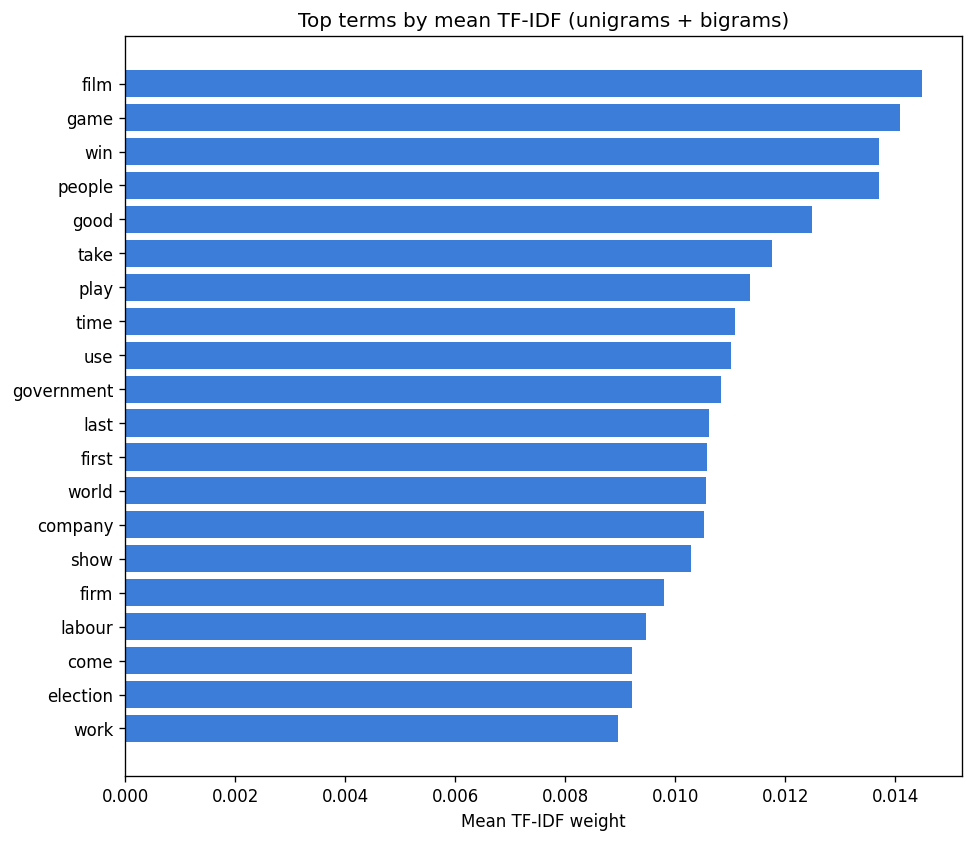

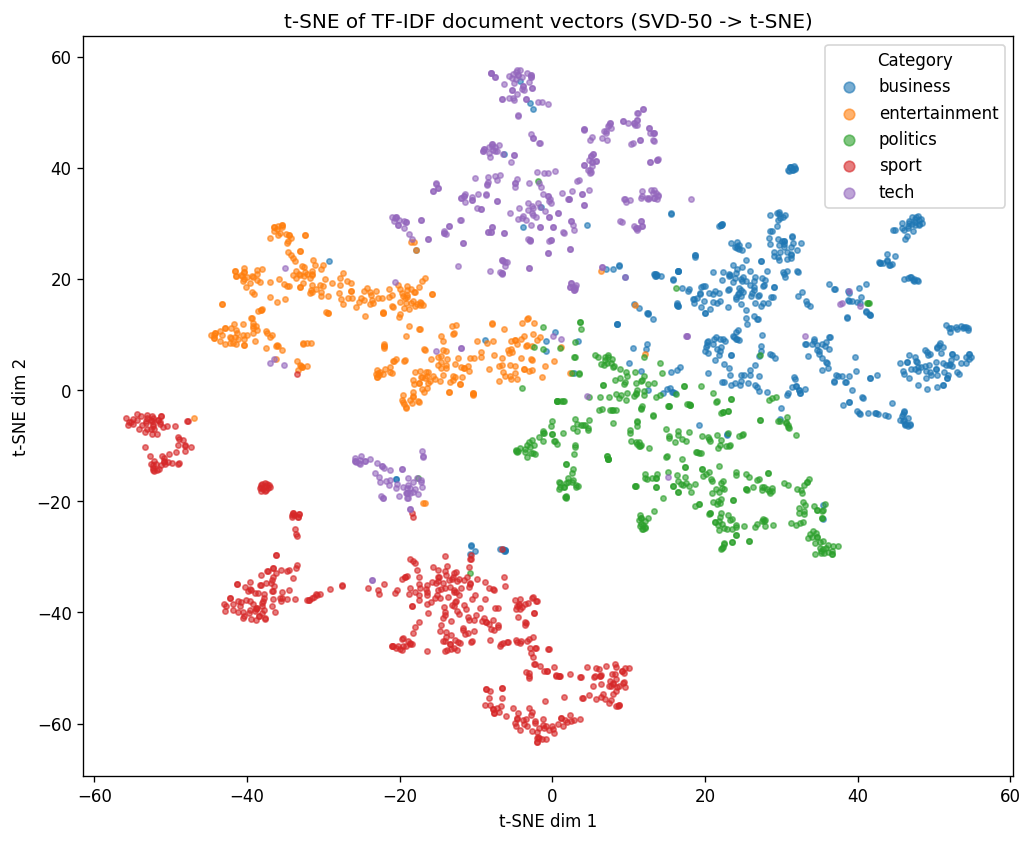

In [19]:
# Display saved figures inline
for _name in ["04_tfidf_top_terms.png", "04_tsne.png"]:
    display(Image(filename=str(FIG_DIR / _name)))

## 5. Modelagem: classificação supervisionada e modelagem de tópicos

Esta etapa cobre **duas frentes** do requisito 3: classificação supervisionada e
modelagem de tópicos. Optamos por **não** usar análise de sentimento porque a
prosa jornalística é majoritariamente neutra — o sentimento lexical (VADER)
agregaria ruído, não sinal.

Para a **classificação** representamos cada documento com **TF-IDF** sobre o
texto já normalizado e lematizado (`clean_text`), usando unigramas e bigramas
(`ngram_range=(1,2)`, até 20000 termos). O TF-IDF é a escolha natural para texto
jornalístico: pondera termos discriminativos e penaliza palavras ubíquas, e os
bigramas capturam expressões (*prime minister*, *world cup*) que separam bem as
cinco editorias. Comparamos três classificadores clássicos e complementares:
**MultinomialNB** (baseline probabilístico rápido e forte em contagens de
texto), **LinearSVC** (margem máxima, excelente em espaços esparsos de alta
dimensão) e **LogisticRegression** com `class_weight="balanced"`. O corpus tem
leve desbalanceamento (*sport* 511 vs *entertainment* 386); o
`class_weight="balanced"` reescala a perda pelo inverso da frequência de cada
classe, evitando que o modelo favoreça as categorias maiores. A divisão foi
estratificada (`test_size=0.25`, `random_state=42`) para preservar essa
distribuição em treino e teste.

Os três modelos ficaram acima de 98% de acurácia, o que mostra que as editorias
da BBC são linguisticamente muito separáveis. O **LinearSVC venceu** (F1-macro
0.9874), errando apenas 6 dos 557 documentos de teste. A matriz de confusão
revela que *entertainment*, *sport* e *tech* foram classificados sem erros, e que
a única confusão recorrente é **politics ↔ business** — coerente, pois ambas
compartilham vocabulário de economia, governo e mercado. O SVM linear se destaca
porque maximiza a margem entre classes em espaços esparsos, exatamente o cenário
do TF-IDF.

Na **modelagem de tópicos** ajustamos **LDA** (sobre contagens) e **NMF** (sobre
TF-IDF), ambos com 5 tópicos para espelhar as 5 classes conhecidas. O NMF
recuperou de forma quase perfeita as cinco editorias, com tópicos limpos para
esporte, política, tecnologia, entretenimento e negócios. O LDA chegou a
estrutura semelhante, mas misturou esporte e entretenimento em alguns tópicos. A
lição é que, mesmo **sem rótulos**, a estrutura temática latente do corpus
reproduz a taxonomia editorial — confirmando que as categorias supervisionadas
correspondem a agrupamentos linguísticos reais, e não a divisões arbitrárias.


In [20]:
# --- Imports ---
from __future__ import annotations

from pathlib import Path

import matplotlib

matplotlib.use("Agg")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import NMF, LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

In [21]:
# --- Setup ---
PROJECT_ROOT = NB_ROOT
DF = pd.read_parquet(PROJECT_ROOT / "data" / "processed.parquet")
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
MODEL_DIR = PROJECT_ROOT / "outputs" / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_TOPICS = 5
TOP_WORDS = 10
CATEGORIES = sorted(DF["category"].unique())


def save_fig(fig: plt.Figure, filename: str) -> Path:
    """Persist ``fig`` to the figures directory with the project conventions."""
    path = FIG_DIR / filename
    fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.close(fig)
    return path

In [22]:
# --- Features and split ---
def build_features() -> tuple:
    """Vectorize ``clean_text`` with TF-IDF and produce a stratified split.

    Returns the fitted vectorizer plus the train/test feature matrices and
    label vectors. The split is stratified on ``category`` so that the mild
    class imbalance is preserved identically in train and test.
    """
    vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
    features = vectorizer.fit_transform(DF["clean_text"])
    labels = DF["category"].to_numpy()

    x_train, x_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=labels,
    )
    return vectorizer, x_train, x_test, y_train, y_test

In [23]:
# --- Train and compare classifiers ---
def build_classifiers() -> dict:
    """Return the three classifiers to compare, keyed by display name."""
    return {
        "MultinomialNB": MultinomialNB(),
        "LinearSVC": LinearSVC(dual=True, random_state=RANDOM_STATE),
        "LogisticRegression": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    }


def evaluate_classifiers(x_train, x_test, y_train, y_test) -> tuple:
    """Fit every classifier and collect metrics and predictions.

    Returns ``(models, predictions, comparison)`` where ``comparison`` is a
    DataFrame holding accuracy plus macro precision/recall/F1 per model.
    """
    models = build_classifiers()
    predictions: dict[str, np.ndarray] = {}
    rows: list[dict] = []

    for name, model in models.items():
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        predictions[name] = y_pred

        report = classification_report(
            y_test, y_pred, output_dict=True, zero_division=0
        )
        macro = report["macro avg"]
        rows.append(
            {
                "model": name,
                "accuracy": report["accuracy"],
                "macro_precision": macro["precision"],
                "macro_recall": macro["recall"],
                "macro_f1": macro["f1-score"],
            }
        )

    comparison = pd.DataFrame(rows).set_index("model").round(4)
    return models, predictions, comparison

In [24]:
# --- Confusion matrices ---
def plot_confusion_matrices(y_test, predictions: dict, best_name: str) -> list[Path]:
    """Save a confusion-matrix figure per model plus a dedicated best-model one."""
    paths: list[Path] = []

    for name, y_pred in predictions.items():
        matrix = confusion_matrix(y_test, y_pred, labels=CATEGORIES)
        disp = ConfusionMatrixDisplay(matrix, display_labels=CATEGORIES)
        fig, ax = plt.subplots(figsize=(6, 5))
        disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
        ax.set_title(f"Confusion matrix - {name}")
        slug = name.lower()
        paths.append(save_fig(fig, f"05_confusion_matrix_{slug}.png"))

    # Dedicated best-model figure under the contracted filename.
    best_matrix = confusion_matrix(y_test, predictions[best_name], labels=CATEGORIES)
    disp = ConfusionMatrixDisplay(best_matrix, display_labels=CATEGORIES)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
    ax.set_title(f"Confusion matrix - best model ({best_name})")
    paths.append(save_fig(fig, "05_confusion_matrix_best.png"))
    return paths

In [25]:
# --- Metrics comparison chart ---
def plot_metrics_comparison(comparison: pd.DataFrame) -> Path:
    """Save a grouped bar chart of accuracy + macro P/R/F1 across models."""
    metrics = ["accuracy", "macro_precision", "macro_recall", "macro_f1"]
    models = comparison.index.tolist()
    x = np.arange(len(models))
    width = 0.2

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, metric in enumerate(metrics):
        offset = (i - (len(metrics) - 1) / 2) * width
        ax.bar(x + offset, comparison[metric].to_numpy(), width, label=metric)

    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel("Score")
    ax.set_title("Classifier comparison (test set)")
    ax.legend(loc="lower right")
    ax.grid(axis="y", alpha=0.3)
    return save_fig(fig, "05_metrics_comparison.png")

In [26]:
# --- Topic modeling ---
def fit_topic_models() -> tuple:
    """Fit LDA on counts and NMF on TF-IDF, both with 5 topics.

    Returns ``(lda, lda_terms, nmf, nmf_terms)`` where each ``*_terms`` is the
    feature-name array aligned to the model component columns.
    """
    count_vectorizer = CountVectorizer(max_features=20000)
    counts = count_vectorizer.fit_transform(DF["clean_text"])
    lda = LatentDirichletAllocation(
        n_components=N_TOPICS, random_state=RANDOM_STATE, learning_method="batch"
    )
    lda.fit(counts)

    tfidf_vectorizer = TfidfVectorizer(max_features=20000)
    tfidf = tfidf_vectorizer.fit_transform(DF["clean_text"])
    nmf = NMF(n_components=N_TOPICS, random_state=RANDOM_STATE, init="nndsvda", max_iter=400)
    nmf.fit(tfidf)

    return (
        lda,
        np.array(count_vectorizer.get_feature_names_out()),
        nmf,
        np.array(tfidf_vectorizer.get_feature_names_out()),
    )


def top_words_per_topic(model, terms: np.ndarray, n: int = TOP_WORDS) -> list[list[str]]:
    """Return the ``n`` highest-weighted words for each topic component."""
    topics: list[list[str]] = []
    for component in model.components_:
        top_idx = component.argsort()[::-1][:n]
        topics.append(terms[top_idx].tolist())
    return topics


def print_topics(label: str, topics: list[list[str]]) -> None:
    """Print top words per topic for a fitted model."""
    print(f"\n[{label}] top-{TOP_WORDS} words per topic")
    for i, words in enumerate(topics):
        print(f"  Topic {i}: {', '.join(words)}")


def plot_topics(topics: list[list[str]], model, terms: np.ndarray, title: str) -> Path:
    """Save horizontal bar subplots of top words per topic for one model."""
    fig, axes = plt.subplots(1, N_TOPICS, figsize=(4 * N_TOPICS, 5), sharex=False)
    for i, ax in enumerate(axes):
        component = model.components_[i]
        top_idx = component.argsort()[::-1][:TOP_WORDS]
        words = terms[top_idx][::-1]
        weights = component[top_idx][::-1]
        ax.barh(range(len(words)), weights, color="tab:blue")
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=9)
        ax.set_title(f"Topic {i}")
        ax.tick_params(axis="x", labelsize=8)
    fig.suptitle(title)
    return save_fig(fig, "05_topics_nmf.png")

In [27]:
# --- Main ---
def main() -> None:
    """Run both modeling fronts end to end and persist all artifacts."""
    print(f"Corpus: {len(DF)} docs across {len(CATEGORIES)} categories")
    print("Class counts:\n", DF["category"].value_counts().to_string())

    # --- (A) Supervised classification ---
    vectorizer, x_train, x_test, y_train, y_test = build_features()
    print(f"\nTF-IDF features: {x_train.shape[1]} | "
          f"train={x_train.shape[0]} test={x_test.shape[0]}")

    models, predictions, comparison = evaluate_classifiers(
        x_train, x_test, y_train, y_test
    )
    print("\n=== Metrics comparison (test set) ===")
    print(comparison.to_string())

    best_name = comparison["macro_f1"].idxmax()
    print(f"\nBest model by macro F1: {best_name}")

    plot_confusion_matrices(y_test, predictions, best_name)
    plot_metrics_comparison(comparison)

    # Persist the best classifier and the vectorizer that produced its features.
    joblib.dump(models[best_name], MODEL_DIR / "clf_best.joblib")
    joblib.dump(vectorizer, MODEL_DIR / "clf_vectorizer.joblib")
    print(f"Saved best model ({best_name}) + vectorizer to {MODEL_DIR}")

    # --- (B) Topic modeling ---
    lda, lda_terms, nmf, nmf_terms = fit_topic_models()
    lda_topics = top_words_per_topic(lda, lda_terms)
    nmf_topics = top_words_per_topic(nmf, nmf_terms)
    print_topics("LDA (counts)", lda_topics)
    print_topics("NMF (TF-IDF)", nmf_topics)

    plot_topics(nmf_topics, nmf, nmf_terms, "NMF topics - top words")

    print("\nDone.")


main()

Corpus: 2225 docs across 5 categories
Class counts:
 category
sport            511
business         510
politics         417
tech             401
entertainment    386



TF-IDF features: 20000 | train=1668 test=557



=== Metrics comparison (test set) ===
                    accuracy  macro_precision  macro_recall  macro_f1
model                                                                
MultinomialNB         0.9820           0.9819        0.9811    0.9815
LinearSVC             0.9874           0.9878        0.9873    0.9874
LogisticRegression    0.9838           0.9837        0.9838    0.9837

Best model by macro F1: LinearSVC


Saved best model (LinearSVC) + vectorizer to /Users/anderson.correa/andersonfpcorrea/infnet-deliveries/26E2_2/outputs/models



[LDA (counts)] top-10 words per topic
  Topic 0: good, film, win, play, game, award, star, time, take, first
  Topic 1: company, firm, market, rise, sale, bank, share, month, price, growth
  Topic 2: labour, party, government, election, people, minister, blair, tory, plan, tell
  Topic 3: win, first, play, set, open, last, final, game, match, take
  Topic 4: use, people, game, mobile, technology, phone, service, user, take, music

[NMF (TF-IDF)] top-10 words per topic
  Topic 0: game, win, england, play, player, match, team, ireland, cup, final
  Topic 1: labour, election, blair, party, tory, brown, minister, government, howard, tax
  Topic 2: mobile, phone, people, use, technology, music, service, digital, user, broadband
  Topic 3: film, award, good, oscar, star, actor, win, festival, actress, director
  Topic 4: growth, economy, rise, rate, bank, price, economic, market, fall, sale



Done.


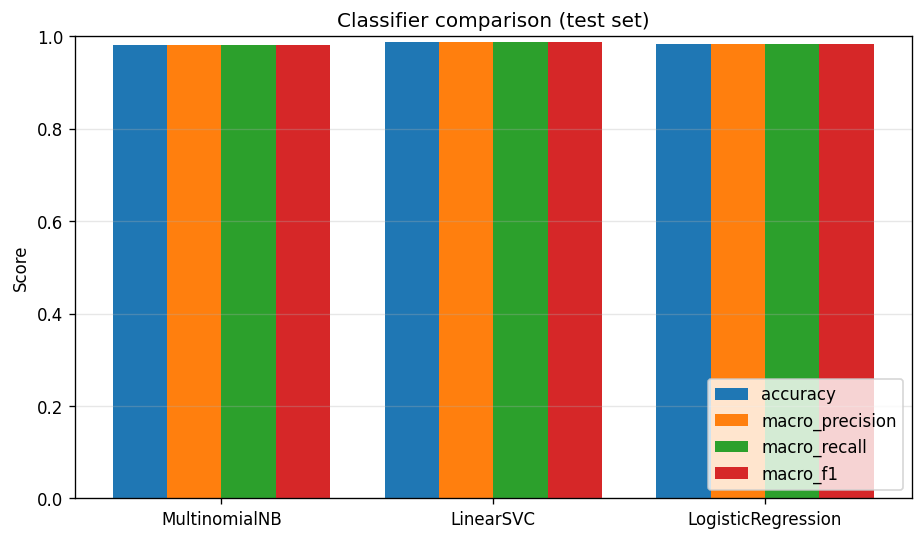

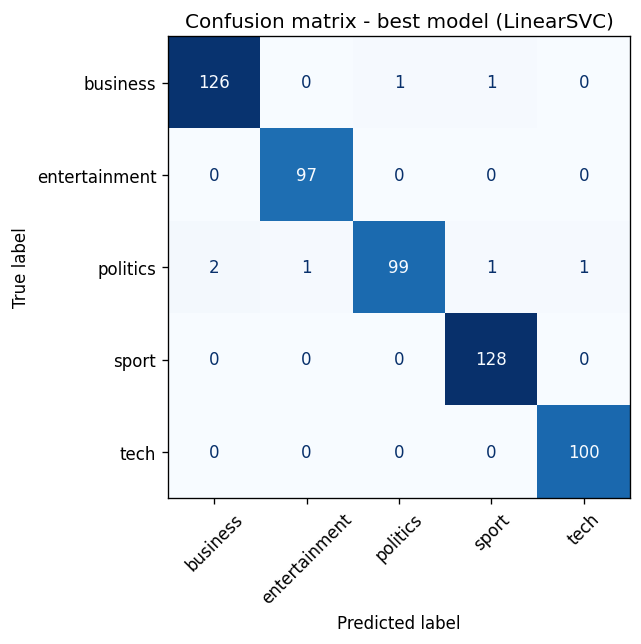

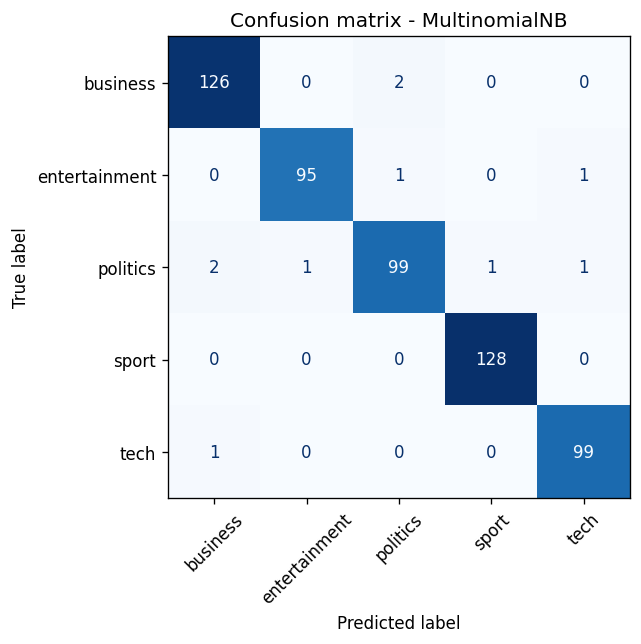

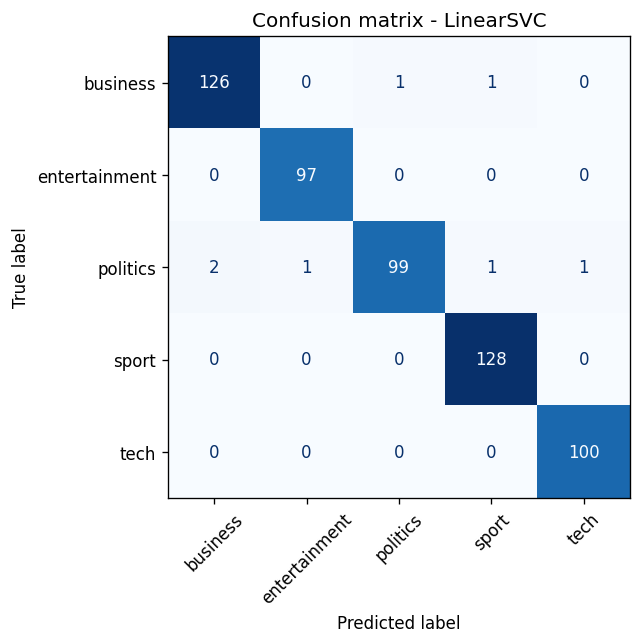

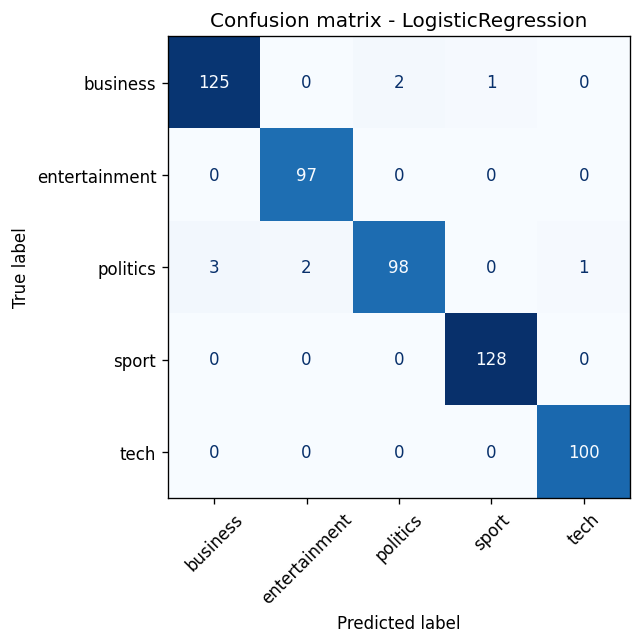

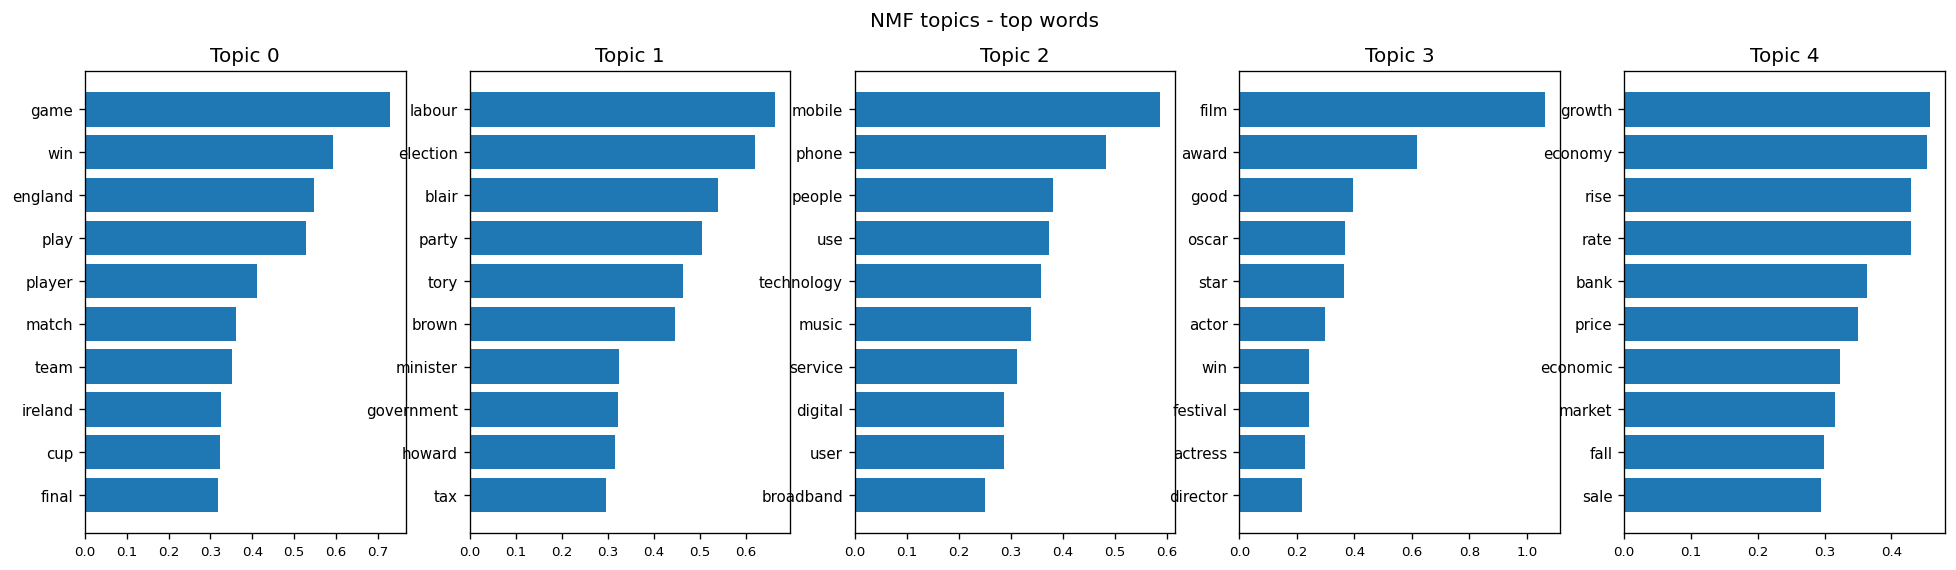

In [28]:
# Display saved figures inline
for _name in ["05_metrics_comparison.png", "05_confusion_matrix_best.png", "05_confusion_matrix_multinomialnb.png", "05_confusion_matrix_linearsvc.png", "05_confusion_matrix_logisticregression.png", "05_topics_nmf.png"]:
    display(Image(filename=str(FIG_DIR / _name)))

## 6. Reconhecimento de entidades e grafo de conhecimento

Aplicamos o reconhecedor de entidades nomeadas (NER) do spaCy
(`en_core_web_sm`) sobre o **texto bruto** dos 2.225 documentos da BBC, usando
`nlp.pipe` com `batch_size=64` e desativando *parser*, *tagger* e *lemmatizer*
para ganhar velocidade — mantendo `tok2vec` e `ner`, que são os componentes
necessários ao reconhecimento. O resultado mostra um corpus jornalístico típico:
predominam **PERSON** e **ORG**, seguidos de **DATE** e **GPE**. As entidades
mais frequentes — *US*, *UK*, *England*, *Labour*, *Britain* — revelam de imediato
o eixo geopolítico britânico e internacional que organiza a cobertura.

Em paralelo ao NER estatístico, aplicamos **extração por expressões regulares**
para campos estruturados que o NER nem sempre normaliza bem: valores monetários
(ex.: `$1.13bn`, `£600m`), percentuais (ex.: `76%`, `2%`), datas (ex.: `Friday`),
além de e-mails e URLs. Isso confirma a forte presença de números financeiros e
estatísticos no jornalismo econômico e esportivo da BBC.

Antes de construir o grafo, fizemos uma etapa de **normalização difusa (fuzzy)**
com a biblioteca `rapidfuzz`. As formas de superfície foram primeiro limpas de
pronomes de tratamento e sufixos corporativos (*Mr*, *Inc*, *Corp* etc.) e depois
agrupadas por similaridade `token_sort_ratio >= 88`, unindo variantes como
"Tony Blair"/"Mr Blair" ou "Microsoft"/"Microsoft Corp". Essa etapa reduz
milhares de formas de superfície a um conjunto canônico, diminuindo o ruído da
análise de rede.

O **grafo de conhecimento** (NetworkX) usa como nós as entidades canônicas mais
frequentes (tipos PERSON, ORG, GPE, NORP, LOC, FAC, EVENT) e como arestas a
**coocorrência no mesmo documento**, ponderada pela contagem e filtrando arestas
fracas (peso < 3). Calculamos duas centralidades: **grau** (conectores mais
densos) e **intermediação/betweenness** (pontes entre comunidades).

A leitura combinada é reveladora. Pela centralidade de grau dominam entidades
nacionais — *UK*, *Europe*, *US*, *London* —, mostrando que a cobertura gira em
torno de um núcleo britânico de alcance internacional. Já a centralidade de
intermediação destaca pontes temáticas: *Liverpool*, *Oscar*, *Google* e
*Hollywood* ligam clusters distintos (esporte, entretenimento, tecnologia). Ou
seja: os hubs nacionais conectam tudo de forma densa, enquanto entidades de nicho
funcionam como elos entre os diferentes domínios noticiosos. Visualizamos o grafo
de forma estática (matplotlib) e interativa (PyVis), além de exportá-lo em
GraphML para análise posterior.

**Pergunta analítica respondida pelo grafo:** *Quais entidades são os principais
conectores na cobertura da BBC e o que isso revela?* A resposta: os conectores
mais centrais por grau são entidades geopolíticas (UK, US, Europe, London),
confirmando uma agenda noticiosa centrada no Reino Unido e de enquadramento
internacional; já a centralidade de intermediação aponta entidades de nicho
(Liverpool, Oscar, Google) como pontes que ligam comunidades temáticas distintas.


In [29]:
# --- Setup and imports ---
import matplotlib

matplotlib.use("Agg")

import re
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import nltk
import pandas as pd
import spacy
from pyvis.network import Network
from rapidfuzz import fuzz

PROJECT_ROOT = NB_ROOT
nltk.data.path.insert(0, str(PROJECT_ROOT / "nltk_data"))

DF = pd.read_parquet(PROJECT_ROOT / "data" / "processed.parquet")
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
GRAPH_DIR = PROJECT_ROOT / "outputs" / "graph"
FIG_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
RAW_TEXTS = DF["text"].fillna("").tolist()

# Entity labels we keep for the knowledge graph (named, content-bearing types).
GRAPH_LABELS = {"PERSON", "ORG", "GPE", "NORP", "FAC", "LOC", "EVENT"}

In [30]:
# --- spaCy NER over the corpus ---
def run_ner(texts, batch_size=64):
    """Run spaCy NER over the raw corpus and return per-document entities.

    The parser, tagger and lemmatizer are disabled for speed; tok2vec and ner
    are kept because the NER component depends on token vectors.

    Args:
        texts: Iterable of raw document strings.
        batch_size: Batch size passed to ``nlp.pipe``.

    Returns:
        List of per-document lists of ``(entity_text, label)`` tuples.
    """
    nlp = spacy.load(
        "en_core_web_sm",
        disable=["parser", "tagger", "lemmatizer", "attribute_ruler"],
    )
    doc_entities = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        ents = [(ent.text.strip(), ent.label_) for ent in doc.ents if ent.text.strip()]
        doc_entities.append(ents)
    return doc_entities


def aggregate_entities(doc_entities):
    """Aggregate entity counts by label and by surface form per label.

    Args:
        doc_entities: Output of :func:`run_ner`.

    Returns:
        Tuple of (label_counter, per_label_surface_counters, overall_counter).
    """
    label_counter = Counter()
    per_label = defaultdict(Counter)
    overall = Counter()
    for ents in doc_entities:
        for text, label in ents:
            label_counter[label] += 1
            per_label[label][text] += 1
            overall[text] += 1
    return label_counter, per_label, overall


def plot_entity_types(label_counter, path):
    """Save a bar chart of entity-label frequencies."""
    labels, counts = zip(*label_counter.most_common())
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(labels, counts, color="#4C72B0")
    ax.set_title("Entity frequency by spaCy label (BBC corpus)")
    ax.set_xlabel("Entity label")
    ax.set_ylabel("Mentions")
    plt.xticks(rotation=45, ha="right")
    for i, c in enumerate(counts):
        ax.text(i, c, f"{c:,}", ha="center", va="bottom", fontsize=8)
    fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.close(fig)


def plot_top_entities(per_label, key_labels, path, top_n=10):
    """Save a grid of bar charts with the top entities for key labels."""
    n = len(key_labels)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, label in zip(axes, key_labels):
        items = per_label[label].most_common(top_n)
        names = [name for name, _ in items][::-1]
        vals = [cnt for _, cnt in items][::-1]
        ax.barh(names, vals, color="#55A868")
        ax.set_title(f"Top {label}")
        ax.set_xlabel("Mentions")
    fig.suptitle("Most frequent entities per key type (BBC corpus)")
    fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.close(fig)

In [31]:
# --- Regex pattern extraction ---
# Money: optional currency symbol/word + number + optional magnitude suffix.
MONEY_RE = re.compile(
    r"(?:[$£€]|\bUS\$)\s?\d[\d,]*(?:\.\d+)?\s?(?:bn|billion|m|million|k|trillion|tn)?"
    r"|\b\d[\d,]*(?:\.\d+)?\s?(?:dollars|pounds|euros|pence|cents)\b",
    re.IGNORECASE,
)
PERCENT_RE = re.compile(
    r"\d+(?:\.\d+)?\s?%|\b\d+(?:\.\d+)?\s?(?:per\s?cent|percent)\b", re.IGNORECASE
)
DATE_RE = re.compile(
    r"\b(?:\d{1,2}\s)?(?:January|February|March|April|May|June|July|August|"
    r"September|October|November|December)\s?(?:\d{1,2})?,?\s?\d{4}\b"
    r"|\b\d{1,2}/\d{1,2}/\d{2,4}\b"
    r"|\b(?:Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday)\b",
    re.IGNORECASE,
)
EMAIL_RE = re.compile(r"\b[\w.+-]+@[\w-]+\.[\w.-]+\b")
URL_RE = re.compile(r"\b(?:https?://|www\.)[^\s,)]+", re.IGNORECASE)

REGEX_PATTERNS = {
    "money": MONEY_RE,
    "percentage": PERCENT_RE,
    "date": DATE_RE,
    "email": EMAIL_RE,
    "url": URL_RE,
}


def extract_patterns(texts):
    """Extract regex-based structured fields from the corpus.

    Args:
        texts: Iterable of raw document strings.

    Returns:
        Dict mapping pattern name to a list of all matched strings.
    """
    matches = {name: [] for name in REGEX_PATTERNS}
    for text in texts:
        for name, pattern in REGEX_PATTERNS.items():
            matches[name].extend(m.strip() for m in pattern.findall(text))
    return matches

In [32]:
# --- Fuzzy normalization of entity surface forms ---
def _normalize_key(name):
    """Lower-case a surface form and strip common honorifics/suffixes."""
    cleaned = re.sub(
        r"\b(mr|mrs|ms|dr|sir|the|inc|corp|ltd|plc|co|group|"
        r"company|corporation)\b\.?",
        "",
        name.lower(),
    )
    cleaned = re.sub(r"[^a-z0-9 ]", " ", cleaned)
    return re.sub(r"\s+", " ", cleaned).strip()


def normalize_entities(overall_counter, threshold=88):
    """Cluster near-duplicate surface forms into canonical entities.

    Surface forms are sorted by frequency; each new form is matched against
    existing cluster representatives using token-sort fuzzy ratio (after a
    light honorific/suffix normalization). Forms above ``threshold`` collapse
    into the most frequent representative.

    Args:
        overall_counter: Counter of surface form -> mention count.
        threshold: Minimum rapidfuzz ratio (0-100) to merge two forms.

    Returns:
        Tuple of (surface_to_canonical map, canonical_counter, n_merged) where
        n_merged is the number of surface forms that collapsed into another.
    """
    forms = [f for f, _ in overall_counter.most_common()]
    surface_to_canonical = {}
    canonical_counter = Counter()
    reps = []  # list of (canonical_surface, normalized_key)

    n_merged = 0
    for form in forms:
        key = _normalize_key(form)
        if not key:
            continue
        best_rep = None
        best_score = 0.0
        for rep_form, rep_key in reps:
            score = fuzz.token_sort_ratio(key, rep_key)
            if score > best_score:
                best_score, best_rep = score, rep_form
        if best_rep is not None and best_score >= threshold:
            surface_to_canonical[form] = best_rep
            canonical_counter[best_rep] += overall_counter[form]
            n_merged += 1
        else:
            surface_to_canonical[form] = form
            canonical_counter[form] += overall_counter[form]
            reps.append((form, key))
    return surface_to_canonical, canonical_counter, n_merged

In [33]:
# --- Knowledge graph from entity co-occurrence ---
def build_graph(doc_entities, surface_to_canonical, canonical_counter,
                top_n=55, min_edge_weight=3):
    """Build a co-occurrence knowledge graph of the most frequent entities.

    Nodes are the ``top_n`` most frequent canonical entities (restricted to
    graph-relevant labels). An edge connects two entities that appear in the
    same document; the edge weight is the number of co-occurring documents.
    Edges below ``min_edge_weight`` are dropped to keep the graph readable.

    Args:
        doc_entities: Output of :func:`run_ner`.
        surface_to_canonical: Map produced by :func:`normalize_entities`.
        canonical_counter: Canonical entity -> total mention count.
        top_n: Number of nodes to keep.
        min_edge_weight: Minimum co-occurrence count for an edge to be kept.

    Returns:
        A weighted, undirected :class:`networkx.Graph`.
    """
    # Determine the canonical label of each canonical entity (majority vote).
    label_votes = defaultdict(Counter)
    for ents in doc_entities:
        for text, label in ents:
            canon = surface_to_canonical.get(text)
            if canon is not None and label in GRAPH_LABELS:
                label_votes[canon][label] += 1

    eligible = [c for c in canonical_counter if label_votes.get(c)]
    eligible.sort(key=lambda c: canonical_counter[c], reverse=True)
    top_entities = eligible[:top_n]
    top_set = set(top_entities)

    edge_weights = Counter()
    for ents in doc_entities:
        present = set()
        for text, label in ents:
            canon = surface_to_canonical.get(text)
            if canon in top_set and label in GRAPH_LABELS:
                present.add(canon)
        for a, b in combinations(sorted(present), 2):
            edge_weights[(a, b)] += 1

    graph = nx.Graph()
    for ent in top_entities:
        top_label = label_votes[ent].most_common(1)[0][0]
        graph.add_node(ent, label=top_label, mentions=canonical_counter[ent])
    for (a, b), w in edge_weights.items():
        if w >= min_edge_weight:
            graph.add_edge(a, b, weight=w)
    return graph

In [34]:
# --- Centrality ---
def compute_centrality(graph):
    """Compute degree and betweenness centrality.

    Args:
        graph: A NetworkX graph.

    Returns:
        Tuple of (degree_centrality dict, betweenness_centrality dict).
    """
    degree = nx.degree_centrality(graph)
    betweenness = nx.betweenness_centrality(graph, weight="weight", seed=RANDOM_STATE)
    return degree, betweenness

In [35]:
# --- Visualization ---
def plot_graph_static(graph, degree, path):
    """Render the knowledge graph with matplotlib, sizing nodes by centrality."""
    fig, ax = plt.subplots(figsize=(16, 12))
    pos = nx.spring_layout(graph, k=0.6, weight="weight", seed=RANDOM_STATE)
    sizes = [3000 * degree.get(n, 0) + 120 for n in graph.nodes()]

    labels = sorted({graph.nodes[n]["label"] for n in graph.nodes()})
    palette = plt.cm.tab10.colors
    color_map = {lab: palette[i % len(palette)] for i, lab in enumerate(labels)}
    node_colors = [color_map[graph.nodes[n]["label"]] for n in graph.nodes()]
    edge_widths = [0.3 + 0.25 * graph[u][v]["weight"] for u, v in graph.edges()]

    nx.draw_networkx_edges(graph, pos, width=edge_widths, alpha=0.25, ax=ax)
    nx.draw_networkx_nodes(graph, pos, node_size=sizes, node_color=node_colors,
                           alpha=0.9, ax=ax)
    nx.draw_networkx_labels(graph, pos, font_size=8, ax=ax)

    handles = [plt.Line2D([0], [0], marker="o", color="w", label=lab,
                          markerfacecolor=color_map[lab], markersize=10)
               for lab in labels]
    ax.legend(handles=handles, title="Entity type", loc="upper right")
    ax.set_title("BBC knowledge graph - entity co-occurrence (node size = degree centrality)")
    ax.axis("off")
    fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.close(fig)


def plot_graph_interactive(graph, degree, path):
    """Render an interactive PyVis HTML visualization of the graph."""
    net = Network(height="800px", width="100%", bgcolor="#ffffff",
                  font_color="#222222", notebook=False, cdn_resources="in_line")
    labels = sorted({graph.nodes[n]["label"] for n in graph.nodes()})
    palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3",
               "#937860", "#DA8BC3", "#8C8C8C"]
    color_map = {lab: palette[i % len(palette)] for i, lab in enumerate(labels)}
    for n in graph.nodes():
        lab = graph.nodes[n]["label"]
        net.add_node(n, label=n, color=color_map[lab],
                     size=10 + 60 * degree.get(n, 0),
                     title=f"{n} ({lab}) - {graph.nodes[n]['mentions']} mentions")
    for u, v in graph.edges():
        w = graph[u][v]["weight"]
        net.add_edge(u, v, value=w, title=f"co-occurs in {w} docs")
    net.force_atlas_2based()
    net.save_graph(str(path))

In [36]:
# --- Reporting helpers ---
def top_by_value(d, top_n=10):
    """Return the top ``top_n`` (key, value) pairs sorted descending by value."""
    return sorted(d.items(), key=lambda kv: kv[1], reverse=True)[:top_n]

In [37]:
# --- Main pipeline ---
def main():
    """Run the full NER and knowledge-graph pipeline and print a report."""
    print(f"Corpus: {len(RAW_TEXTS)} documents")

    print("Running spaCy NER ...")
    doc_entities = run_ner(RAW_TEXTS)
    label_counter, per_label, overall = aggregate_entities(doc_entities)

    print("\n=== Entity-label distribution ===")
    for label, count in label_counter.most_common():
        print(f"{label:>8}: {count:,}")

    print("\n=== Top 10 entities overall ===")
    for name, count in overall.most_common(10):
        print(f"{count:>5}  {name}")

    key_labels = ["PERSON", "ORG", "GPE"]
    plot_entity_types(label_counter, FIG_DIR / "06_entity_types.png")
    plot_top_entities(per_label, key_labels, FIG_DIR / "06_top_entities.png")

    print("\n=== Regex pattern extraction ===")
    matches = extract_patterns(RAW_TEXTS)
    for name, vals in matches.items():
        examples = [v for v in vals if v][:3]
        print(f"{name:>11}: {len(vals):,} matches | examples: {examples}")

    print("\n=== Fuzzy normalization ===")
    surface_to_canonical, canonical_counter, n_merged = normalize_entities(overall)
    print(f"Distinct surface forms : {len(overall):,}")
    print(f"Canonical entities     : {len(canonical_counter):,}")
    print(f"Surface forms merged   : {n_merged:,}")

    print("\nBuilding knowledge graph ...")
    graph = build_graph(doc_entities, surface_to_canonical, canonical_counter)
    print(f"Graph: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")
    assert graph.number_of_nodes() >= 20, "Graph must have at least 20 nodes"

    degree, betweenness = compute_centrality(graph)
    print("\n=== Top 10 by degree centrality ===")
    for name, val in top_by_value(degree):
        print(f"{val:.4f}  {name}")
    print("\n=== Top 10 by betweenness centrality ===")
    for name, val in top_by_value(betweenness):
        print(f"{val:.4f}  {name}")

    plot_graph_static(graph, degree, FIG_DIR / "06_knowledge_graph.png")
    plot_graph_interactive(graph, degree, GRAPH_DIR / "knowledge_graph.html")
    nx.write_graphml(graph, GRAPH_DIR / "knowledge_graph.graphml")

    print("\nArtifacts written:")
    for p in [
        FIG_DIR / "06_entity_types.png",
        FIG_DIR / "06_top_entities.png",
        FIG_DIR / "06_knowledge_graph.png",
        GRAPH_DIR / "knowledge_graph.html",
        GRAPH_DIR / "knowledge_graph.graphml",
    ]:
        print(f"  {p}")


main()

Corpus: 2225 documents
Running spaCy NER ...



=== Entity-label distribution ===
  PERSON: 20,435
     ORG: 18,979
    DATE: 13,536
     GPE: 12,795
CARDINAL: 8,149
    NORP: 4,557
   MONEY: 2,645
 ORDINAL: 2,397
 PERCENT: 1,949
     LOC: 1,099
    TIME: 821
   EVENT: 754
WORK_OF_ART: 706
 PRODUCT: 653
     FAC: 615
QUANTITY: 249
     LAW: 150
LANGUAGE: 118

=== Top 10 entities overall ===
 1496  US
 1073  first
 1035  UK
  802  two
  755  one
  546  England
  532  Labour
  474  second
  439  British
  406  Britain

=== Regex pattern extraction ===


      money: 2,704 matches | examples: ['$1.13bn', '£600m', '$639m']
 percentage: 1,971 matches | examples: ['76%', '2%', '8%']
       date: 1,861 matches | examples: ['Friday', 'Thursday', 'Friday']
      email: 0 matches | examples: []
        url: 3 matches | examples: ['www.arsenal.com:', 'www.dec.org.uk', 'www.dec.org.uk']

=== Fuzzy normalization ===


Distinct surface forms : 23,569
Canonical entities     : 18,769
Surface forms merged   : 4,794

Building knowledge graph ...
Graph: 55 nodes, 757 edges

=== Top 10 by degree centrality ===
0.9259  UK
0.8889  Europe
0.8704  US
0.8704  London
0.8704  European
0.8519  British
0.7963  Britain
0.7963  BBC
0.7593  Australia
0.7407  BBC News

=== Top 10 by betweenness centrality ===
0.1359  Liverpool
0.0597  Germany
0.0534  India
0.0435  Australia
0.0412  Japan
0.0406  Oscar
0.0383  Iraq
0.0367  Google
0.0339  French
0.0329  France

Artifacts written:
  /Users/anderson.correa/andersonfpcorrea/infnet-deliveries/26E2_2/outputs/figures/06_entity_types.png
  /Users/anderson.correa/andersonfpcorrea/infnet-deliveries/26E2_2/outputs/figures/06_top_entities.png
  /Users/anderson.correa/andersonfpcorrea/infnet-deliveries/26E2_2/outputs/figures/06_knowledge_graph.png
  /Users/anderson.correa/andersonfpcorrea/infnet-deliveries/26E2_2/outputs/graph/knowledge_graph.html
  /Users/anderson.correa/andersonfp

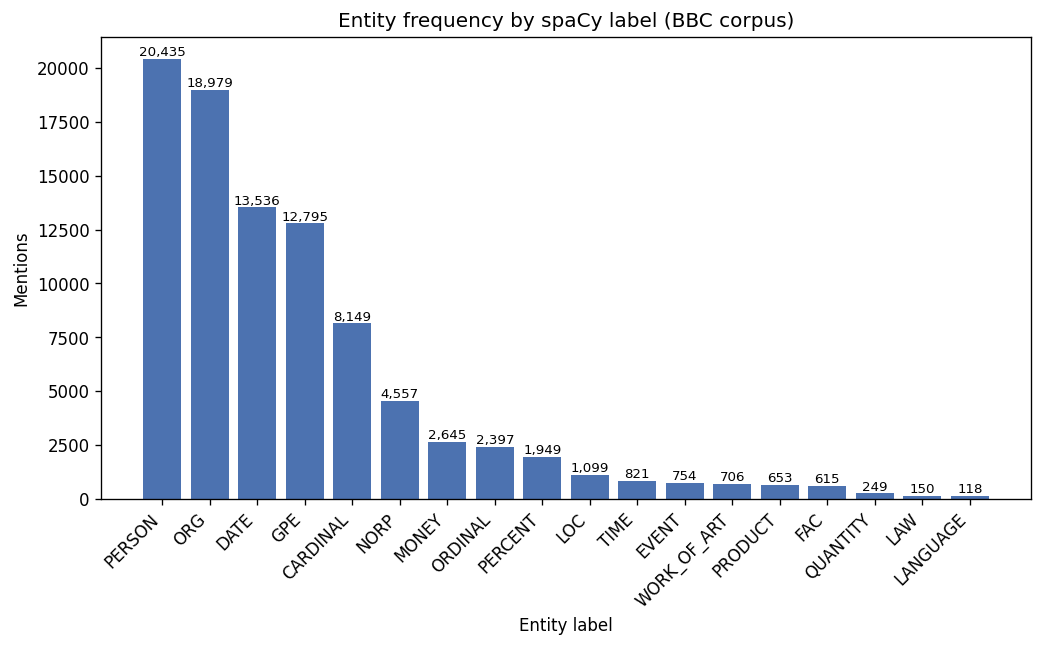

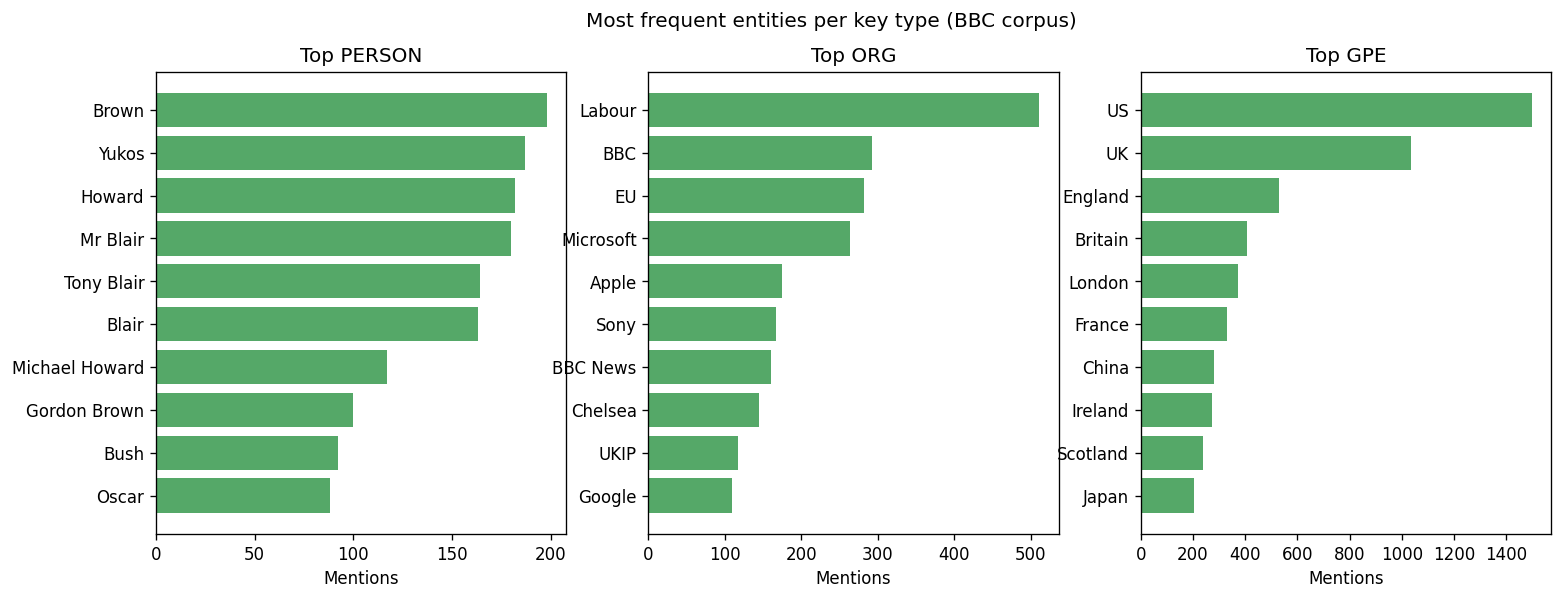

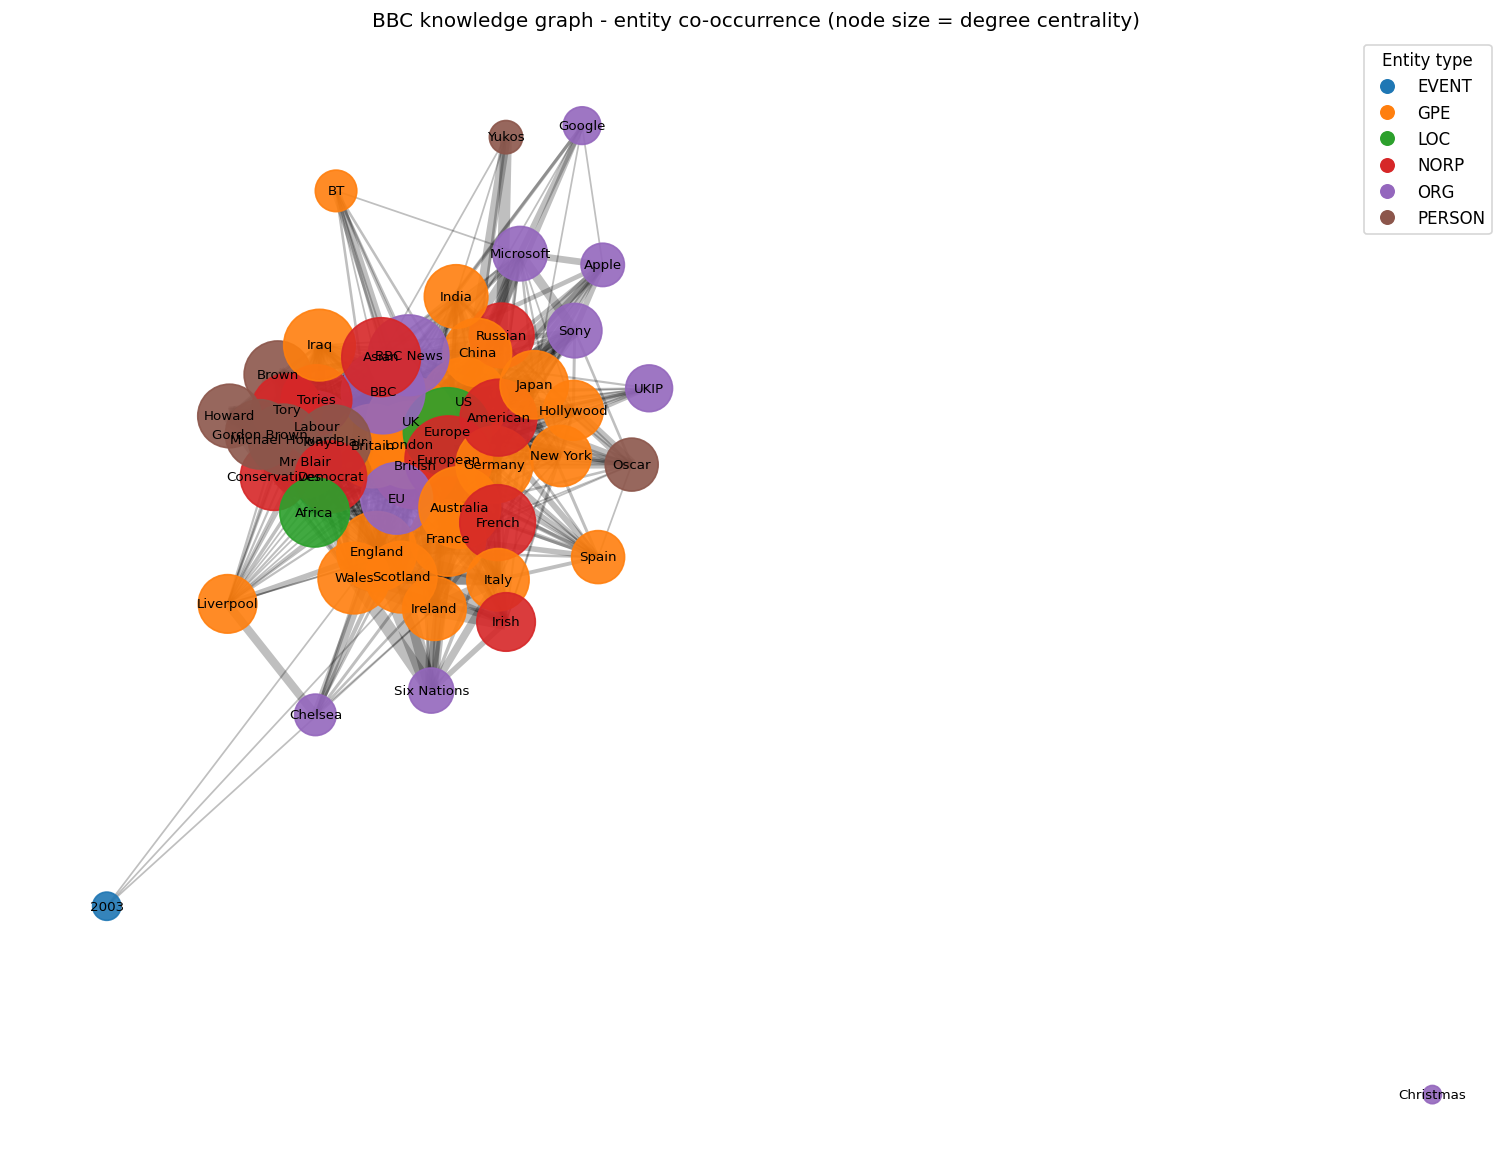

In [38]:
# Display saved figures inline
for _name in ["06_entity_types.png", "06_top_entities.png", "06_knowledge_graph.png"]:
    display(Image(filename=str(FIG_DIR / _name)))

O grafo também foi exportado em formato **interativo** (`outputs/graph/knowledge_graph.html`, abrível no navegador) e em **GraphML** (`outputs/graph/knowledge_graph.graphml`) para análise externa.

## 7. Síntese e comunicação dos resultados

### Síntese em linguagem não técnica

Imagine uma redação com **2.225 reportagens** misturadas e a tarefa de organizá-las,
encontrá-las e entendê-las automaticamente. Foi isso que este pipeline fez, em
quatro movimentos:

1. **Organizar a linguagem.** Primeiro, "limpamos" os textos — removendo palavras
   sem valor informativo e reduzindo cada palavra à sua forma essencial — para que
   o computador comparasse ideias, não ruído.

2. **Encontrar por significado.** Construímos um buscador que, a partir de uma
   frase como *"mercado financeiro e juros"*, devolve as reportagens mais
   relevantes — e ele acerta o tema: pergunta sobre economia traz notícias de
   economia; pergunta sobre celulares traz notícias de tecnologia.

3. **Classificar com altíssima precisão.** Um modelo aprende a adivinhar a
   editoria de uma notícia (esporte, política, economia, tecnologia,
   entretenimento) e acerta **mais de 98%** das vezes. O único engano recorrente
   acontece entre *política* e *economia* — justamente porque, na vida real, esses
   assuntos se misturam (governo, impostos, mercado). Surpreendentemente, quando
   pedimos ao computador para descobrir os temas **sem nenhuma pista**, ele
   reencontra praticamente as mesmas cinco editorias: prova de que essas
   categorias refletem divisões reais da linguagem, não rótulos arbitrários.

4. **Mapear quem é quem.** Extraímos automaticamente as pessoas, empresas e
   lugares citados e desenhamos um "mapa de relações". Esse mapa mostra que a
   cobertura gira em torno de um eixo britânico e internacional (Reino Unido, EUA,
   Europa), enquanto nomes mais específicos (Liverpool, Oscar, Google) funcionam
   como "pontes" que conectam mundos diferentes — esporte, cinema e tecnologia.

**Conclusão para o decisor:** é possível, com ferramentas abertas e sem
infraestrutura cara, transformar uma pilha de textos em um sistema que busca,
classifica e mapeia informação de forma confiável e interpretável. O mesmo
pipeline se aplica, com ajustes mínimos, a chamados de suporte, avaliações de
clientes, reclamações ou documentos internos.

### Principais achados técnicos

- As cinco editorias são **linguisticamente muito separáveis** (F1-macro ≈ 0,99).
- Métodos supervisionados e não supervisionados **convergem** para a mesma
  estrutura de cinco temas — uma triangulação que valida os rótulos.
- A confusão *política ↔ economia* é o único ponto sistemático e é
  **semanticamente justificável**.
- O grafo de conhecimento expõe a **geografia editorial** da BBC: hubs nacionais
  densos e entidades de nicho como pontes entre domínios.

### Limitações e melhorias futuras

O corpus vem de uma única fonte (BBC, 2004-2005), então os modelos não
generalizam para outros veículos ou épocas sem reavaliação. O grafo baseia-se em
coocorrência (heurística), não em relações verificadas; um próximo passo seria
extrair triplas sujeito-verbo-objeto com o parser de dependências para relações
explícitas. Outras melhorias: embeddings contextuais (BERT) para busca semântica
mais fina, validação cruzada estratificada com intervalos de confiança, e um NER
customizado para entidades de domínio específico.
